In [138]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels

Note: you may need to restart the kernel to use updated packages.


In [139]:
# %pip install gdown


In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
# import gdown

# file_id = "11u3Gx55u0SdYEvOETMek5CQD4MCmlmff"
# url = f"https://drive.google.com/uc?id={file_id}"

# output = "Enhanced_Supplement_Sales_Strong_Correlation.csv"
# gdown.download(url, output, quiet=False)

# df = pd.read_csv(output)
# df.head()


In [142]:
df = pd.read_csv("/workspaces/DSCI441-Project-Xirui_Ruoyan/notebooks/Supplement_Sales_Strong_Correlation.csv")
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform,Month
0,2021-01-04,Whey Protein,Protein,139,22.37,2953.69,0.05,1,UK,Amazon,1
1,2021-01-04,Vitamin C,Vitamin,78,34.88,2720.43,0.00,1,UK,Amazon,1
2,2021-01-04,Fish Oil,Omega,70,31.75,2222.57,0.00,1,Canada,Amazon,1
3,2021-01-04,Multivitamin,Vitamin,180,15.22,1917.54,0.30,5,UK,Walmart,1
4,2021-01-04,Pre-Workout,Performance,148,38.22,3960.00,0.30,4,USA,iHerb,1


In [143]:
# calendar = pd.read_csv("/content/drive/MyDrive/441/Project/calendar.csv")
# sales = pd.read_csv("/content/drive/MyDrive/441/Project/sales_train_validation.csv")
# prices = pd.read_csv("/content/drive/MyDrive/441/Project/sell_prices.csv")

# EDA

In [144]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (2496, 11)

Columns:
['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned', 'Location', 'Platform', 'Month']


In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2496 non-null   str    
 1   Product Name    2496 non-null   str    
 2   Category        2496 non-null   str    
 3   Units Sold      2496 non-null   int64  
 4   Price           2496 non-null   float64
 5   Revenue         2496 non-null   float64
 6   Discount        2496 non-null   float64
 7   Units Returned  2496 non-null   int64  
 8   Location        2496 non-null   str    
 9   Platform        2496 non-null   str    
 10  Month           2496 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 214.6 KB


In [146]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct


In [147]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


## 1. Basic

### 1.1. Numerical Variables

In [148]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned', 'Month']

In [149]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,2496.0,85.796074,26.167942,28.00,67.0000,83.00,102.0000,184.00
Price,2496.0,32.806186,10.410877,10.96,23.9800,32.92,41.7425,55.60
Revenue,2496.0,2337.272480,605.837302,1017.86,1890.6975,2274.23,2719.8825,5037.28
Discount,2496.0,0.102003,0.108164,0.00,0.0000,0.05,0.2000,0.30
Units Returned,2496.0,2.058894,1.313159,0.00,1.0000,2.00,3.0000,8.00
Month,2496.0,6.474359,3.439623,1.00,3.7500,6.50,9.2500,12.00


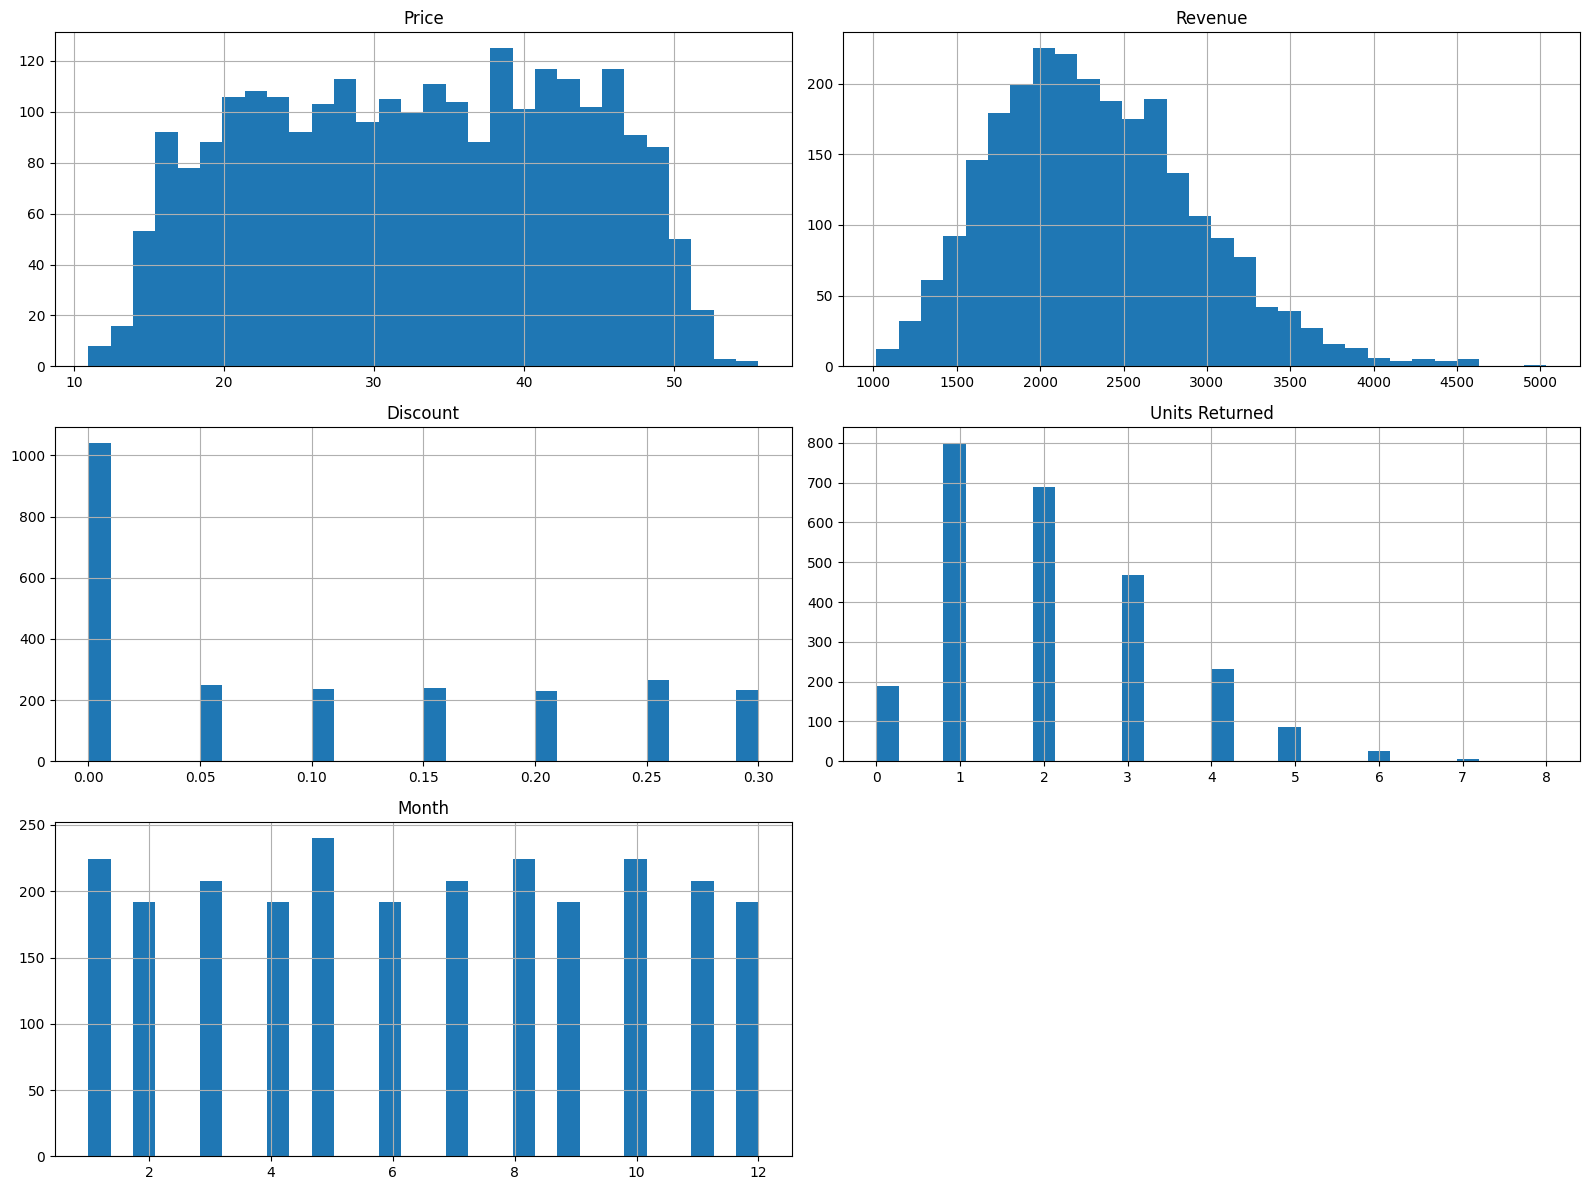

In [150]:
# df[numeric_cols].hist(figsize=(16, 12), bins=30)
df[numeric_cols].drop(columns=['Units Sold']).hist(figsize=(16,12), bins=30)

plt.tight_layout()
plt.show()

### 1.2. Categorical Variables

In [151]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

/tmp/ipykernel_21905/236125719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


['Date', 'Product Name', 'Category', 'Location', 'Platform']

In [152]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 156 unique values
Product Name: 16 unique values
Category: 11 unique values
Location: 3 unique values
Platform: 3 unique values


In [153]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).head(10))


Column: Date
Date
2021-01-04    16
2021-01-11    16
2021-01-18    16
2021-01-25    16
2021-02-01    16
2021-02-08    16
2021-02-15    16
2021-02-22    16
2021-03-01    16
2021-03-08    16
Name: count, dtype: int64

Column: Product Name
Product Name
Whey Protein    156
Vitamin C       156
Fish Oil        156
Multivitamin    156
Pre-Workout     156
BCAA            156
Creatine        156
Zinc            156
Magnesium       156
Probiotic       156
Name: count, dtype: int64

Column: Category
Category
Vitamin        468
Mineral        468
Performance    312
Protein        156
Omega          156
Amino Acid     156
Digestive      156
Herbal         156
Sleep Aid      156
Fat Burner     156
Name: count, dtype: int64

Column: Location
Location
USA       878
UK        809
Canada    809
Name: count, dtype: int64

Column: Platform
Platform
Walmart    848
Amazon     827
iHerb      821
Name: count, dtype: int64


### 1.3. Time Variables

In [154]:
df.columns.tolist()

['Date',
 'Product Name',
 'Category',
 'Units Sold',
 'Price',
 'Revenue',
 'Discount',
 'Units Returned',
 'Location',
 'Platform',
 'Month']

In [155]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].min(), df["Date"].max())

2021-01-04 00:00:00 2023-12-25 00:00:00


In [156]:
df = df.sort_values("Date")
df[["Date"]].head()

,Date
0,2021-01-04
15,2021-01-04
14,2021-01-04
13,2021-01-04
12,2021-01-04


### 1.4. Sales Distribution Analysis

In [157]:
target_col = "Units Sold"
print(df[target_col].describe())

count    2496.000000
mean       85.796074
std        26.167942
min        28.000000
25%        67.000000
50%        83.000000
75%       102.000000
max       184.000000
Name: Units Sold, dtype: float64


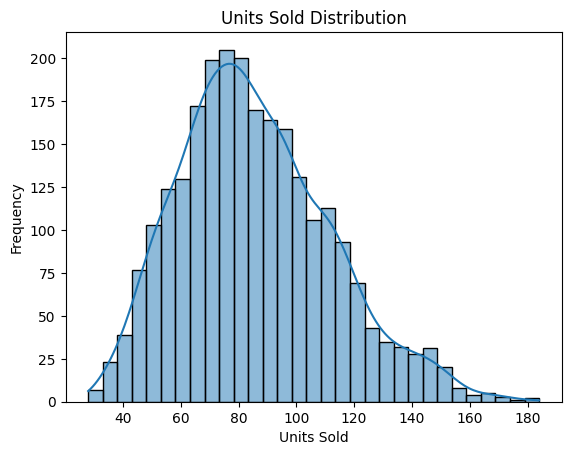

In [158]:
# plt.figure(figsize=(8,5))
# plt.hist(df[target_col], bins=30)
# plt.xlabel("Units Sold")
# plt.ylabel("Frequency")
# plt.title("Distribution of Units Sold")
# plt.show()

sns.histplot(df['Units Sold'], kde=True)

plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

## 2. Relational EDA

### 2.1. Weekly Total Units Sold Over Time

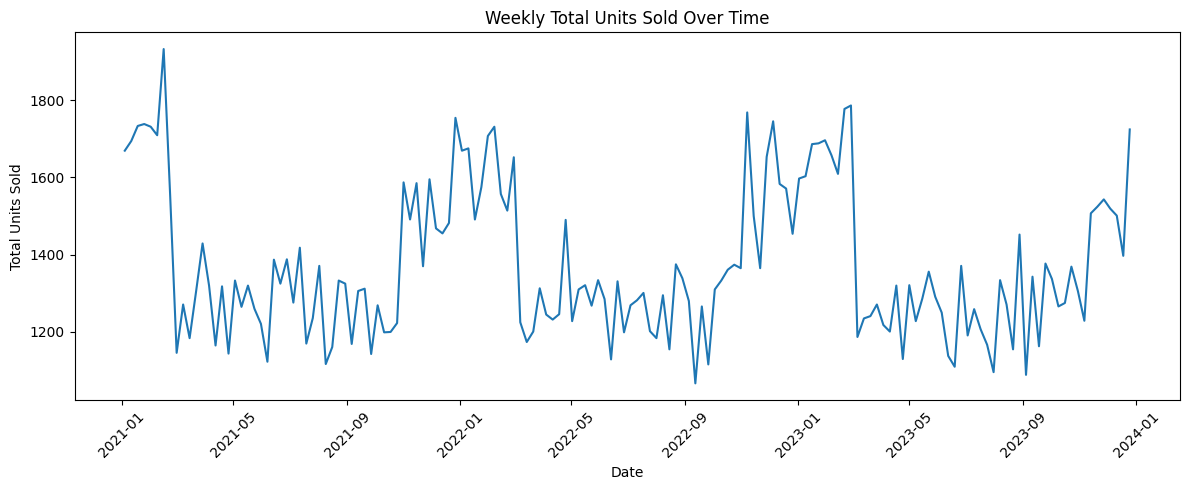

In [159]:
weekly_units = df.groupby("Date")["Units Sold"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_units["Date"], weekly_units["Units Sold"])
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.title("Weekly Total Units Sold Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.2. Total Units Sold by Category

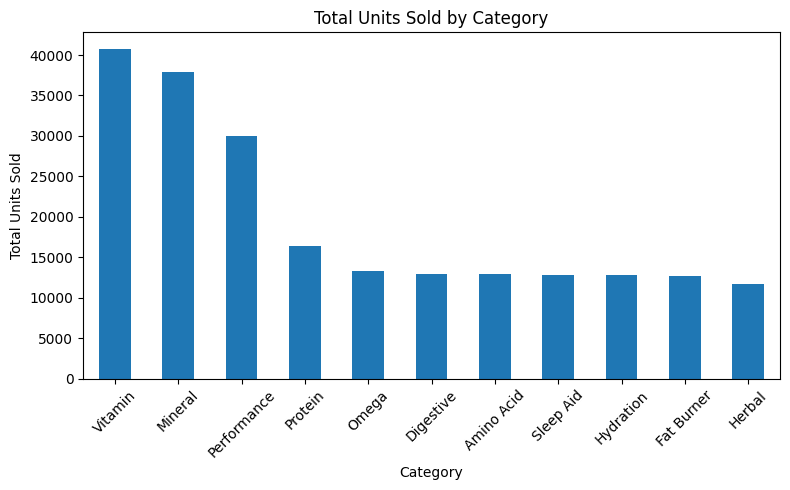

In [160]:
category_sales = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3. Total Units Sold by Product

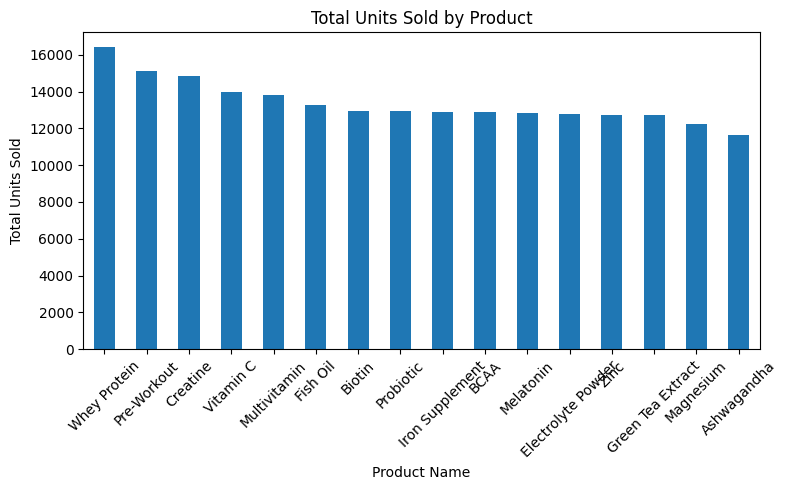

In [161]:
product_sales = df.groupby("Product Name")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
product_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.4. Total Units Sold by Location

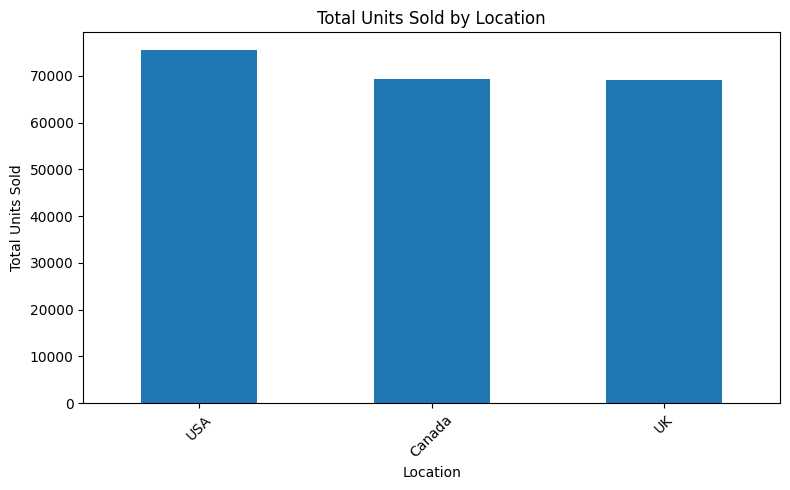

In [162]:
location_sales = df.groupby("Location")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
location_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.5. Total Units Sold by Platform

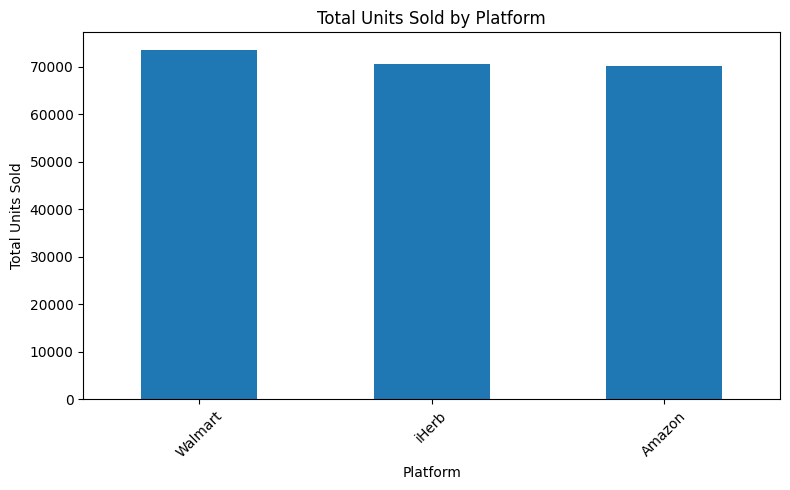

In [163]:
platform_sales = df.groupby("Platform")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
platform_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.6. Price vs Units Sold

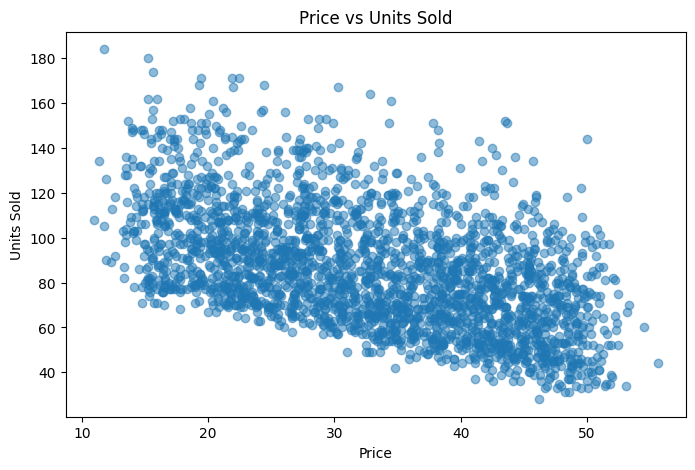

In [164]:
plt.figure(figsize=(8,5))
plt.scatter(df["Price"], df["Units Sold"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

### 2.7. Discount vs Units Sold

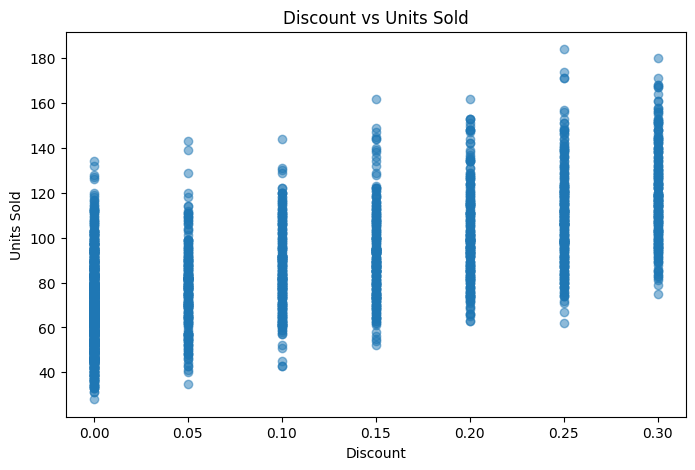

In [165]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Units Sold"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Units Sold")
plt.title("Discount vs Units Sold")
plt.show()

In [166]:
df.groupby("Discount")["Units Sold"].mean().sort_index()

Discount
0.00     69.282692
0.05     77.570281
0.10     85.611814
0.15     92.377593
0.20    101.783550
0.25    109.112782
0.30    119.349138
Name: Units Sold, dtype: float64

### 2.8. Units Returned vs Units Sold

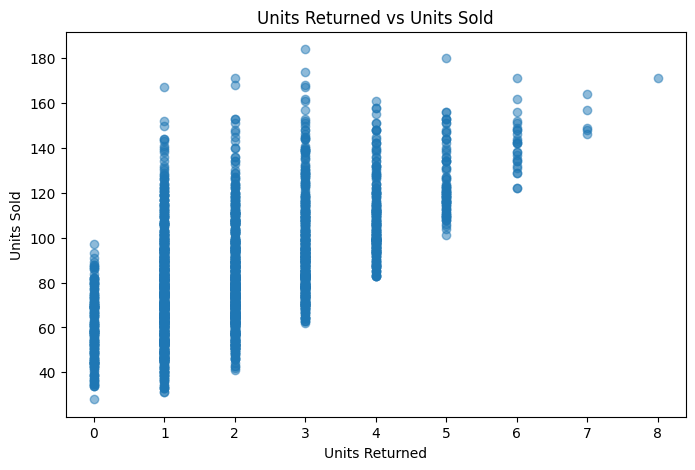

In [167]:
plt.figure(figsize=(8,5))
plt.scatter(df["Units Returned"], df["Units Sold"], alpha=0.5)
plt.xlabel("Units Returned")
plt.ylabel("Units Sold")
plt.title("Units Returned vs Units Sold")
plt.show()

### 2.9. Numerical Variable Correlation

In [168]:
numeric_cols = ["Units Sold", "Price", "Revenue", "Discount", "Units Returned"]
corr = df[numeric_cols].corr()
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,-0.523939,0.193029,0.673419,0.591055
Price,-0.523939,1.000000,0.640371,0.000024,-0.293015
Revenue,0.193029,0.640371,1.000000,0.316329,0.122345
Discount,0.673419,0.000024,0.316329,1.000000,0.423713
Units Returned,0.591055,-0.293015,0.122345,0.423713,1.000000


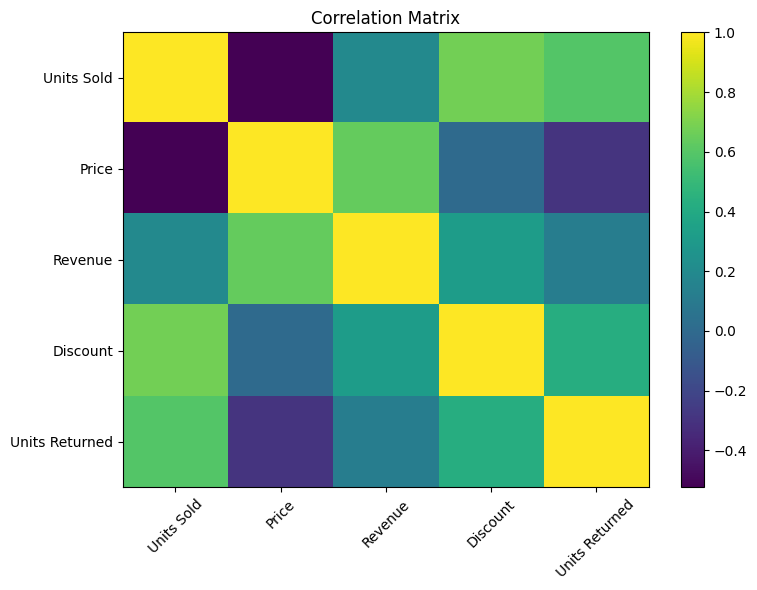

In [169]:
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.10. Weekly Unit sold

#### 2.10.1 By Category

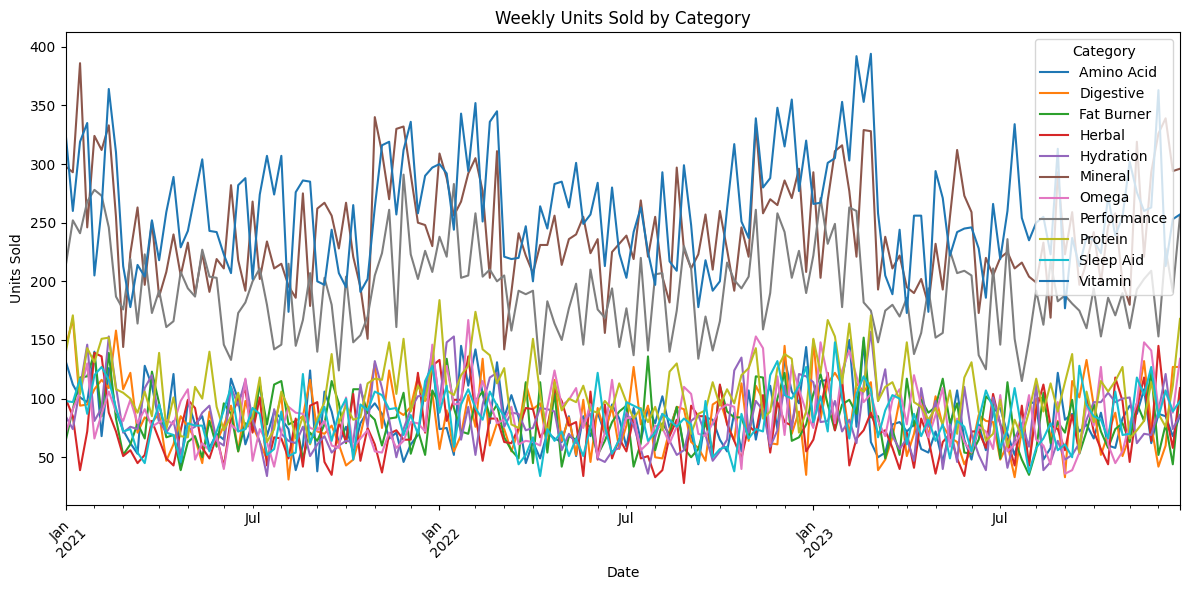

In [170]:
category_trend = df.groupby(["Date", "Category"])["Units Sold"].sum().unstack()

category_trend.plot(figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Weekly Units Sold by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2.10.2 By Platform

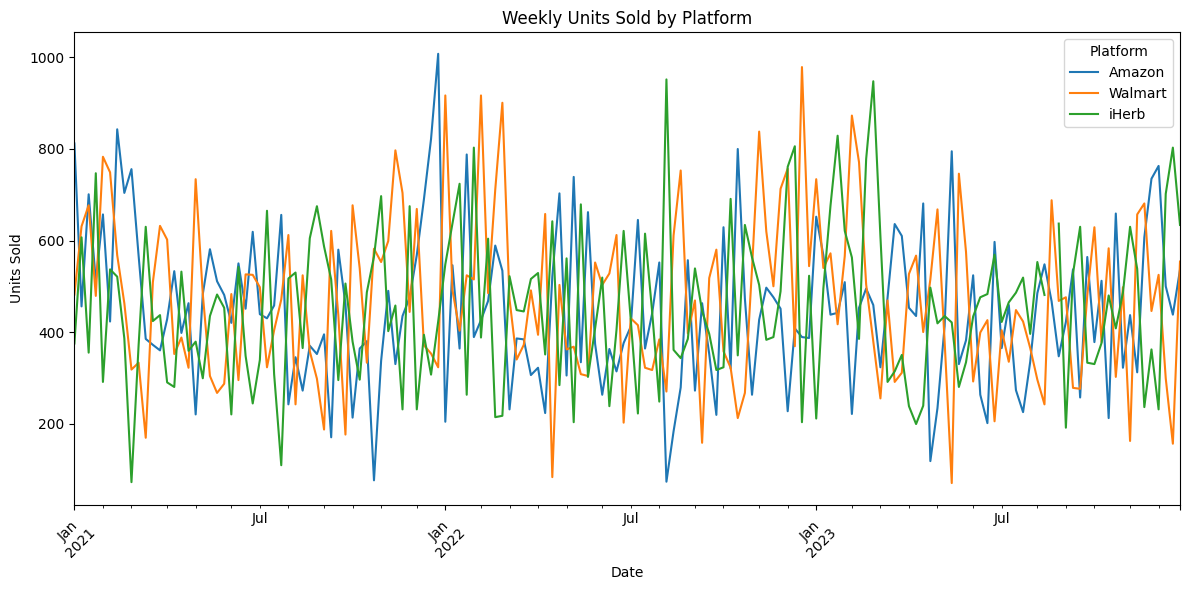

In [171]:
platform_trend = df.groupby(["Date", "Platform"])["Units Sold"].sum().unstack()

platform_trend.plot(figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Weekly Units Sold by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Time-based Features

In [172]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

### 3.1 Total Units Sold by Month

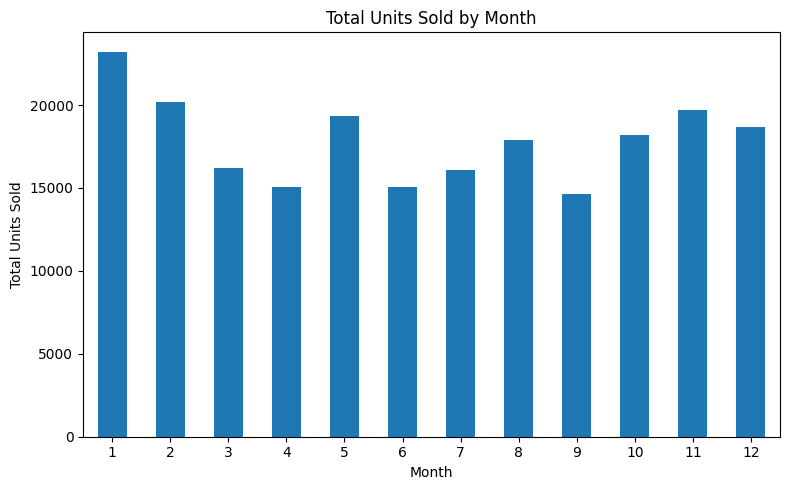

In [173]:
monthly_sales = df.groupby("Month")["Units Sold"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Statistical Analysis

### 4.1 CLT

<Axes: ylabel='Count'>

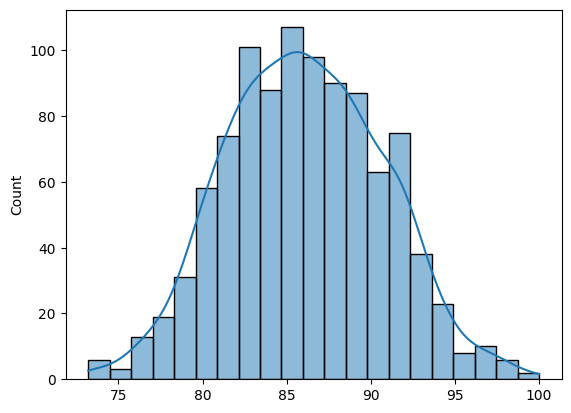

In [174]:
sample_means = []

for i in range(1000):
    sample = df['Units Sold'].sample(30, replace=True)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)

### 4.2 Hypothesis Testing for Differences in Platform Sales
H0: Sales volume is the same across different platforms.
(ANOVA)

In [175]:
from scipy.stats import f_oneway

groups = [g['Units Sold'].values for name, g in df.groupby('Platform')]

f_oneway(*groups)

F_onewayResult(statistic=np.float64(1.1165099766586857), pvalue=np.float64(0.3275841739829427))

### 4.3 Hypothesis Testing on the Impact of Discounts on Sales
H0: Discounts are unrelated to sales volume.(Spearman correlation)

In [176]:
from scipy.stats import spearmanr

spearmanr(df['Discount'], df['Units Sold'])

SignificanceResult(statistic=np.float64(0.6679238902986542), pvalue=np.float64(0.0))

### 4.4 Bootstrapping

In [177]:
boot_means = []

for i in range(1000):
    sample = df['Units Sold'].sample(frac=1, replace=True)
    boot_means.append(sample.mean())

np.percentile(boot_means, [2.5,97.5])

array([84.72691306, 86.84173678])

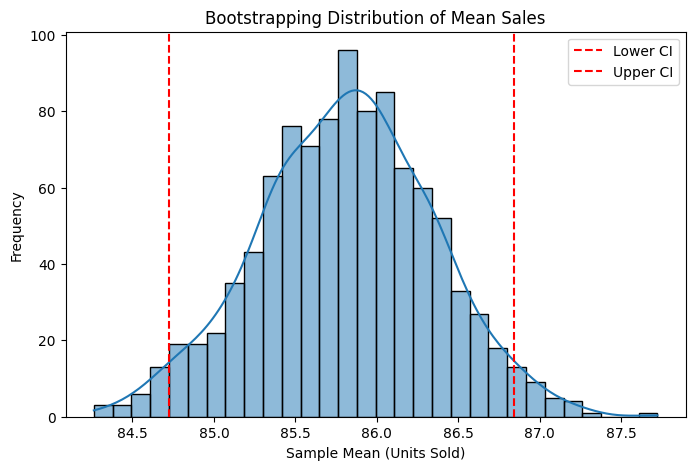

In [178]:
lower, upper = np.percentile(boot_means, [2.5, 97.5])

plt.figure(figsize=(8,5))
sns.histplot(boot_means, bins=30, kde=True)

plt.axvline(lower, color='red', linestyle='--', label='Lower CI')
plt.axvline(upper, color='red', linestyle='--', label='Upper CI')

plt.title("Bootstrapping Distribution of Mean Sales")
plt.xlabel("Sample Mean (Units Sold)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Feature Engineer

### 1. 目标变量
本项目的预测目标为 **`Units Sold`**，表示每个产品在每一周的销量。
### 2. 时间排序
在构造历史特征之前，先按照 **`Product Name`** 和 **`Date`** 对数据进行排序。  
这样可以确保后续生成的 lag 特征和 rolling 特征都严格按照时间顺序计算，避免未来信息混入过去。
### 3. 日历特征
从 `Date` 列中提取了以下时间特征：

- `year`
- `month`
- `quarter`
- `weekofyear`

这些特征可以帮助模型学习销售中的季节性和时间规律。

In [179]:
target_col = "Units Sold"

# 先排序
df = df.sort_values(["Product Name", "Date"]).reset_index(drop=True)

# -------------------
# 1 Calendar features
# -------------------
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)


### 4. 滞后特征（Lag Features）
为了让模型利用历史销量和促销信息，我们在每个产品内部构造了多组滞后特征，包括：

- `units_sold_lag`
- `price_lag`
- `discount_lag`
- `units_returned_lag`


In [180]:
# group_cols = ["Product Name"]   # 先简单版，后面可再调整

# for lag in [1, 2, 4, 8, 12]:
#     df[f"units_sold_lag{lag}"] = df.groupby(group_cols)["Units Sold"].shift(lag)
#     df[f"price_lag{lag}"] = df.groupby(group_cols)["Price"].shift(lag)
#     df[f"discount_lag{lag}"] = df.groupby(group_cols)["Discount"].shift(lag)
#     df[f"units_returned_lag{lag}"] = df.groupby(group_cols)["Units Returned"].shift(lag)

# for window in [4, 8, 12]:
#     df[f"units_sold_rollmean_{window}"] = (
#         df.groupby(group_cols)["Units Sold"]
#           .transform(lambda s: s.shift(1).rolling(window).mean())
#     )
#     df[f"units_sold_rollstd_{window}"] = (
#         df.groupby(group_cols)["Units Sold"]
#           .transform(lambda s: s.shift(1).rolling(window).std())
#     )
#     df[f"units_returned_rollmean_{window}"] = (
#         df.groupby(group_cols)["Units Returned"]
#           .transform(lambda s: s.shift(1).rolling(window).mean())
#     )

In [182]:
import pandas as pd

# 加载新数据集
df = pd.read_csv('Supplement_Sales_Strong_Correlation.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 关键：必须按产品和时间排序，否则 Lag 计算会错乱
df = df.sort_values(by=['Product Name', 'Date'])

def create_time_series_features(df):
    # --- 滞后特征 (Lag Features) ---
    # 预测本周销量时，已知上周、上上周的情况
    df['units_sold_lag1'] = df.groupby('Product Name')['Units Sold'].shift(1)
    df['units_sold_lag2'] = df.groupby('Product Name')['Units Sold'].shift(2)
    df['units_sold_lag4'] = df.groupby('Product Name')['Units Sold'].shift(4)
    
    # 价格和折扣的滞后（模拟现实中只能看到过去价格对现在销量的影响）
    df['price_lag1'] = df.groupby('Product Name')['Price'].shift(1)
    df['discount_lag1'] = df.groupby('Product Name')['Discount'].shift(1)
    
    # --- 滚动特征 (Rolling Features) ---
    # 过去 4 周的平均销量（排除本周，避免泄露）
    df['units_sold_rollmean_4'] = df.groupby('Product Name')['Units Sold'].transform(
        lambda x: x.shift(1).rolling(window=4).mean()
    )
    # 过去 4 周的波动情况
    df['units_sold_rollstd_4'] = df.groupby('Product Name')['Units Sold'].transform(
        lambda x: x.shift(1).rolling(window=4).std()
    )
    
    # --- 日期基础特征 ---
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    
    # 去除因为 shift 产生的空行 (每个产品的前 4 周会变为空)
    df = df.dropna().reset_index(drop=True)
    return df

final_df = create_time_series_features(df)

### 5. 防止数据泄漏
为了保证模型在预测时只使用“预测时刻已知的信息”，我们删除了以下变量：

In [183]:
# -------------------
# 3 Drop current leakage columns
# -------------------
df_model = df.drop(columns=["Revenue", "Units Returned"])

# 如果未来价格/折扣未知，再加这一句
# df_model = df_model.drop(columns=["Price", "Discount"])


In [184]:
# -------------------
# 4 Final feature list
# -------------------
categorical_cols = ["Product Name", "Category", "Location", "Platform"]
calendar_cols = ["year", "month", "quarter", "weekofyear"]
known_current_cols = ["Price","Discount"]   # 如果未来已知就保留 --- IGNORE ---
hist_cols = [c for c in df_model.columns if ("lag" in c or "roll" in c)]

feature_cols = categorical_cols + calendar_cols + known_current_cols + hist_cols

final_df = df_model[["Date", target_col] + feature_cols].dropna().reset_index(drop=True)

X = final_df[feature_cols]
y = final_df[target_col]

# Data Split

In [185]:
# import pandas as pd

# # 假设 final_df 已经包含你做好的所有特征
# final_df["Date"] = pd.to_datetime(final_df["Date"])
# final_df = final_df.sort_values("Date").reset_index(drop=True)

# target_col = "Units Sold"

# feature_cols = [
#     "Product Name", "Category", "Location", "Platform",
#     "Price", "Discount", "year", "month", "quarter", "weekofyear",
#     "units_sold_lag1", "units_sold_lag2", "units_sold_lag4",
#     "units_sold_rollmean_4", "units_sold_rollstd_4",
#     "price_lag1", "discount_lag1", "units_returned_lag1"
# ]

# train_end = "2023-12-31"
# valid_end = "2024-12-31"

# train_df = final_df[final_df["Date"] <= train_end].copy()
# valid_df = final_df[(final_df["Date"] > train_end) & (final_df["Date"] <= valid_end)].copy()
# test_df  = final_df[final_df["Date"] > valid_end].copy()

# X_train = train_df[feature_cols]
# y_train = train_df[target_col]

# X_valid = valid_df[feature_cols]
# y_valid = valid_df[target_col]

# X_test = test_df[feature_cols]
# y_test = test_df[target_col]

# print("Train:", train_df["Date"].min(), "->", train_df["Date"].max(), train_df.shape)
# print("Valid:", valid_df["Date"].min(), "->", valid_df["Date"].max(), valid_df.shape)
# print("Test :", test_df["Date"].min(),  "->", test_df["Date"].max(),  test_df.shape)
# print("X_train shape:", X_train.shape)
# print("X_valid shape:", X_valid.shape)
# print("X_test shape:", X_test.shape)

In [186]:
# 获取数据集中最晚的日期
max_date = final_df['Date'].max()

# 策略：最后 12 周作为 Test，倒数 13-24 周作为 Valid，其余作为 Train
test_cutoff = max_date - pd.Timedelta(weeks=12)
valid_cutoff = test_cutoff - pd.Timedelta(weeks=12)

# 执行切分
train_df = final_df[final_df['Date'] <= valid_cutoff].copy()
valid_df = final_df[(final_df['Date'] > valid_cutoff) & (final_df['Date'] <= test_cutoff)].copy()
test_df  = final_df[final_df['Date'] > test_cutoff].copy()

# 准备特征矩阵
feature_cols = [
    "Product Name", "Category", "Location", "Platform",
    "Price", "Discount", "year", "month", "quarter", "weekofyear",
    "units_sold_lag1", "units_sold_lag2", "units_sold_lag4",
    "units_sold_rollmean_4", "units_sold_rollstd_4",
    "price_lag1", "discount_lag1"
]
target_col = "Units Sold"

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_valid, y_valid = valid_df[feature_cols], valid_df[target_col]
X_test, y_test   = test_df[feature_cols], test_df[target_col]

# 打印检查结果
print(f"train: {train_df['Date'].min().date()} -> {train_df['Date'].max().date()} ({len(train_df)} )")
print(f"validation: {valid_df['Date'].min().date()} -> {valid_df['Date'].max().date()} ({len(valid_df)} )")
print(f"tset: {test_df['Date'].min().date()} -> {test_df['Date'].max().date()} ({len(test_df)} )")

train: 2021-02-01 -> 2023-07-10 (2048 )
validation: 2023-07-17 -> 2023-10-02 (192 )
tset: 2023-10-09 -> 2023-12-25 (192 )


# Rolling Backtesting

### 6. 滚动统计特征（Rolling Features）
除了单点滞后值之外，我们还进一步构造了滚动统计特征，包括：

- `units_sold_rollmean`
- `units_sold_rollstd`
- `units_returned_rollmean`

在计算 rolling 特征时，先进行了 `shift` 操作，再进行滚动窗口统计，确保只使用当前周之前的历史信息，避免数据泄漏。

这些 rolling 特征可以帮助模型更平滑地理解近期趋势和波动情况。

In [187]:
dev_df = final_df[final_df["Date"] <= valid_end].copy()
dev_df = dev_df.sort_values("Date").reset_index(drop=True)

In [188]:
import numpy as np
import pandas as pd

def make_rolling_folds(df, date_col="Date", initial_train_weeks=156, horizon=4, step=4):
    df = df.sort_values(date_col).copy()
    unique_dates = np.array(sorted(df[date_col].unique()))
    
    folds = []
    
    train_end_idx = initial_train_weeks - 1
    
    while train_end_idx + horizon < len(unique_dates):
        train_end_date = unique_dates[train_end_idx]
        val_start_date = unique_dates[train_end_idx + 1]
        val_end_date = unique_dates[train_end_idx + horizon]
        
        folds.append({
            "train_end": train_end_date,
            "val_start": val_start_date,
            "val_end": val_end_date
        })
        
        train_end_idx += step
    
    return folds

In [189]:
folds = make_rolling_folds(
    dev_df,
    date_col="Date",
    initial_train_weeks=156,
    horizon=4,
    step=4
)

print("Number of folds:", len(folds))
print(folds[:3])

Number of folds: 0
[]


### Evaluation Function

In [190]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [191]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2]
    })

### One-Hot encoding 之后开始训练模型1 Regression Model

In [192]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical_features = ["Product Name", "Category", "Location", "Platform"]

numeric_features = [
    col for col in feature_cols 
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

valid_pred_lr = linear_model.predict(X_valid)

linear_result = evaluate_model(y_valid, valid_pred_lr, "Linear Regression")
linear_result

,Model,MAE,RMSE,R2
0,Linear Regression,5.352579,6.910395,0.905873


### 训练模型2：Random Forest

In [193]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

valid_pred_rf = rf_model.predict(X_valid)

rf_result = evaluate_model(y_valid, valid_pred_rf, "Random Forest")
rf_result

,Model,MAE,RMSE,R2
0,Random Forest,5.742058,7.50833,0.88888


### 训练模型3：LightGBM

In [194]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [195]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

lgbm_model.fit(X_train, y_train)

valid_pred_lgbm = lgbm_model.predict(X_valid)

lgbm_result = evaluate_model(y_valid, valid_pred_lgbm, "LightGBM")
lgbm_result

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1545
[LightGBM] [Info] Number of data points in the train set: 2048, number of used features: 46
[LightGBM] [Info] Start training from score 85.528320


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE,RMSE,R2
0,LightGBM,4.451951,5.679702,0.936414


In [196]:
results = pd.concat(
    [linear_result, rf_result, lgbm_result],
    ignore_index=True
)

results = results.sort_values("RMSE").reset_index(drop=True)

results.round(4)

,Model,MAE,RMSE,R2
0,LightGBM,4.4520,5.6797,0.9364
1,Linear Regression,5.3526,6.9104,0.9059
2,Random Forest,5.7421,7.5083,0.8889


# Prediction

In [197]:
# Test set predictions
test_pred_lr = linear_model.predict(X_test)
test_pred_rf = rf_model.predict(X_test)
test_pred_lgbm = lgbm_model.predict(X_test)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [198]:
linear_test_result = evaluate_model(y_test, test_pred_lr, "Linear Regression")
rf_test_result = evaluate_model(y_test, test_pred_rf, "Random Forest")
lgbm_test_result = evaluate_model(y_test, test_pred_lgbm, "LightGBM")

In [199]:
test_results = pd.concat(
    [linear_test_result, rf_test_result, lgbm_test_result],
    ignore_index=True
)

test_results = test_results.sort_values("RMSE").reset_index(drop=True)

test_results.round(4)

,Model,MAE,RMSE,R2
0,LightGBM,5.7498,7.2138,0.9238
1,Linear Regression,7.2732,8.9151,0.8837
2,Random Forest,8.2770,10.5603,0.8368


# Evaluation Framework